In [1]:
print("Mon environnement fonctionne !")

Mon environnement fonctionne !


## Importation des bibliothèques

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [47]:
import os
os.listdir("../data/raw")

['.gitkeep', 'Loan_club_group3.csv']

## Importation de la base de donnée

In [48]:
df = pd.read_csv("../data/raw/Loan_club_group3.csv")
df.head()

,id,loan_amnt,term,int_rate,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,inq_last_6mths,pub_rec,acc_now_delinq,avg_cur_bal,chargeoff_within_12_mths,delinq_amnt,num_accts_ever_120_pd,num_actv_bc_tl,num_bc_sats,pub_rec_bankruptcies
0,40001,19075,60 months,25.80%,G,HRD Coordinator,10+ years,RENT,48000.0,Source Verified,...,1,0,0,1496,1,0,2,3,3,0
1,40002,10800,36 months,15.10%,C,Collector,3 years,RENT,70000.0,Not Verified,...,1,0,0,6837,0,0,5,4,4,0
2,40003,10000,36 months,11.99%,B,Administrator of Health Services,9 years,MORTGAGE,170000.0,Verified,...,1,0,0,22019,0,0,3,5,6,0
3,40004,18000,60 months,16.20%,C,EDUCATION TECH,2 years,MORTGAGE,70000.0,Verified,...,1,0,0,38631,0,0,6,2,2,0
4,40005,8125,36 months,17.76%,D,lvn,4 years,OWN,45000.0,Verified,...,2,0,0,26569,0,0,0,3,3,0


## Exploration Rapide de la base avec les différents variables

In [49]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        20000 non-null  int64  
 1   loan_amnt                 20000 non-null  int64  
 2   term                      20000 non-null  str    
 3   int_rate                  20000 non-null  str    
 4   grade                     20000 non-null  str    
 5   emp_title                 18798 non-null  str    
 6   emp_length                19100 non-null  str    
 7   home_ownership            20000 non-null  str    
 8   annual_inc                20000 non-null  float64
 9   verification_status       20000 non-null  str    
 10  loan_status               20000 non-null  str    
 11  purpose                   20000 non-null  str    
 12  zip_code                  20000 non-null  str    
 13  addr_state                20000 non-null  str    
 14  dti              

In [50]:
df.dtypes

id                            int64
loan_amnt                     int64
term                            str
int_rate                        str
grade                           str
emp_title                       str
emp_length                      str
home_ownership                  str
annual_inc                  float64
verification_status             str
loan_status                     str
purpose                         str
zip_code                        str
addr_state                      str
dti                         float64
delinq_2yrs                   int64
inq_last_6mths                int64
pub_rec                       int64
acc_now_delinq                int64
avg_cur_bal                   int64
chargeoff_within_12_mths      int64
delinq_amnt                   int64
num_accts_ever_120_pd         int64
num_actv_bc_tl                int64
num_bc_sats                   int64
pub_rec_bankruptcies          int64
dtype: object

In [51]:
df.columns

Index(['id', 'loan_amnt', 'term', 'int_rate', 'grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'loan_status', 'purpose', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'acc_now_delinq',
       'avg_cur_bal', 'chargeoff_within_12_mths', 'delinq_amnt',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_bc_sats',
       'pub_rec_bankruptcies'],
      dtype='str')

La base contient 20000 dossiers de prêts ou empreunteur et 25 variables. les colonnes contiennent les caractéristiques des emprunteurs. Nous avons 2 variables qui ont des valeurs numériques à virgule, 13 variables numériques entier et 11 variables qui sont catégoriques ou des textes. La majorité des variables sont complètes mais certains présente des valeurs manquantes. Ilya des veleurs numériques entières, numériques continues et catégorielles. 

In [52]:
# Résumé statistique des variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,20000.0,50000.500000,5773.647028,40001.0,45000.75,50000.50,55000.25,60000.00
loan_amnt,20000.0,14411.725000,7994.638840,1000.0,8325.00,12375.00,20000.00,35000.00
annual_inc,20000.0,71967.243561,42465.937399,8000.0,45000.00,62000.00,86000.00,1000000.00
dti,20000.0,17.031119,7.561756,0.0,11.33,16.69,22.51,34.99
delinq_2yrs,20000.0,0.259900,0.716085,0.0,0.00,0.00,0.00,18.00
inq_last_6mths,20000.0,0.766650,1.022032,0.0,0.00,0.00,1.00,6.00
pub_rec,20000.0,0.139550,0.406920,0.0,0.00,0.00,0.00,6.00
acc_now_delinq,20000.0,0.003700,0.063139,0.0,0.00,0.00,0.00,2.00
avg_cur_bal,20000.0,14058.613550,15885.616979,0.0,3019.75,8302.50,20285.50,329278.00
chargeoff_within_12_mths,20000.0,0.006100,0.088109,0.0,0.00,0.00,0.00,3.00


In [53]:
## Résumé des variables 
df.select_dtypes(exclude="number").describe().T

,count,unique,top,freq
term,20000,2,36 months,14122
int_rate,20000,61,12.35%,916
grade,20000,7,B,6452
emp_title,18798,15702,US Army,59
emp_length,19100,11,10+ years,6875
home_ownership,20000,3,MORTGAGE,10669
verification_status,20000,3,Verified,9003
loan_status,20000,2,Fully Paid,16911
purpose,20000,13,debt_consolidation,12045
zip_code,20000,795,945xx,244


### ANALYSE  EXPLORATOIRE DES DONNEES: DATA QUALITY

L'analyse exploratoire est essentielle. Elle permet de comprendre la donnée, de mettre en évidence les tendances, anomalies, et de préparer la donnée pour la modélisation. Cette section vise à vérifier la qualité des données avant de poursuivre l'analyse statistique.

In [54]:
df.isnull().sum()

id                             0
loan_amnt                      0
term                           0
int_rate                       0
grade                          0
emp_title                   1202
emp_length                   900
home_ownership                 0
annual_inc                     0
verification_status            0
loan_status                    0
purpose                        0
zip_code                       0
addr_state                     0
dti                            0
delinq_2yrs                    0
inq_last_6mths                 0
pub_rec                        0
acc_now_delinq                 0
avg_cur_bal                    0
chargeoff_within_12_mths       0
delinq_amnt                    0
num_accts_ever_120_pd          0
num_actv_bc_tl                 0
num_bc_sats                    0
pub_rec_bankruptcies           0
dtype: int64

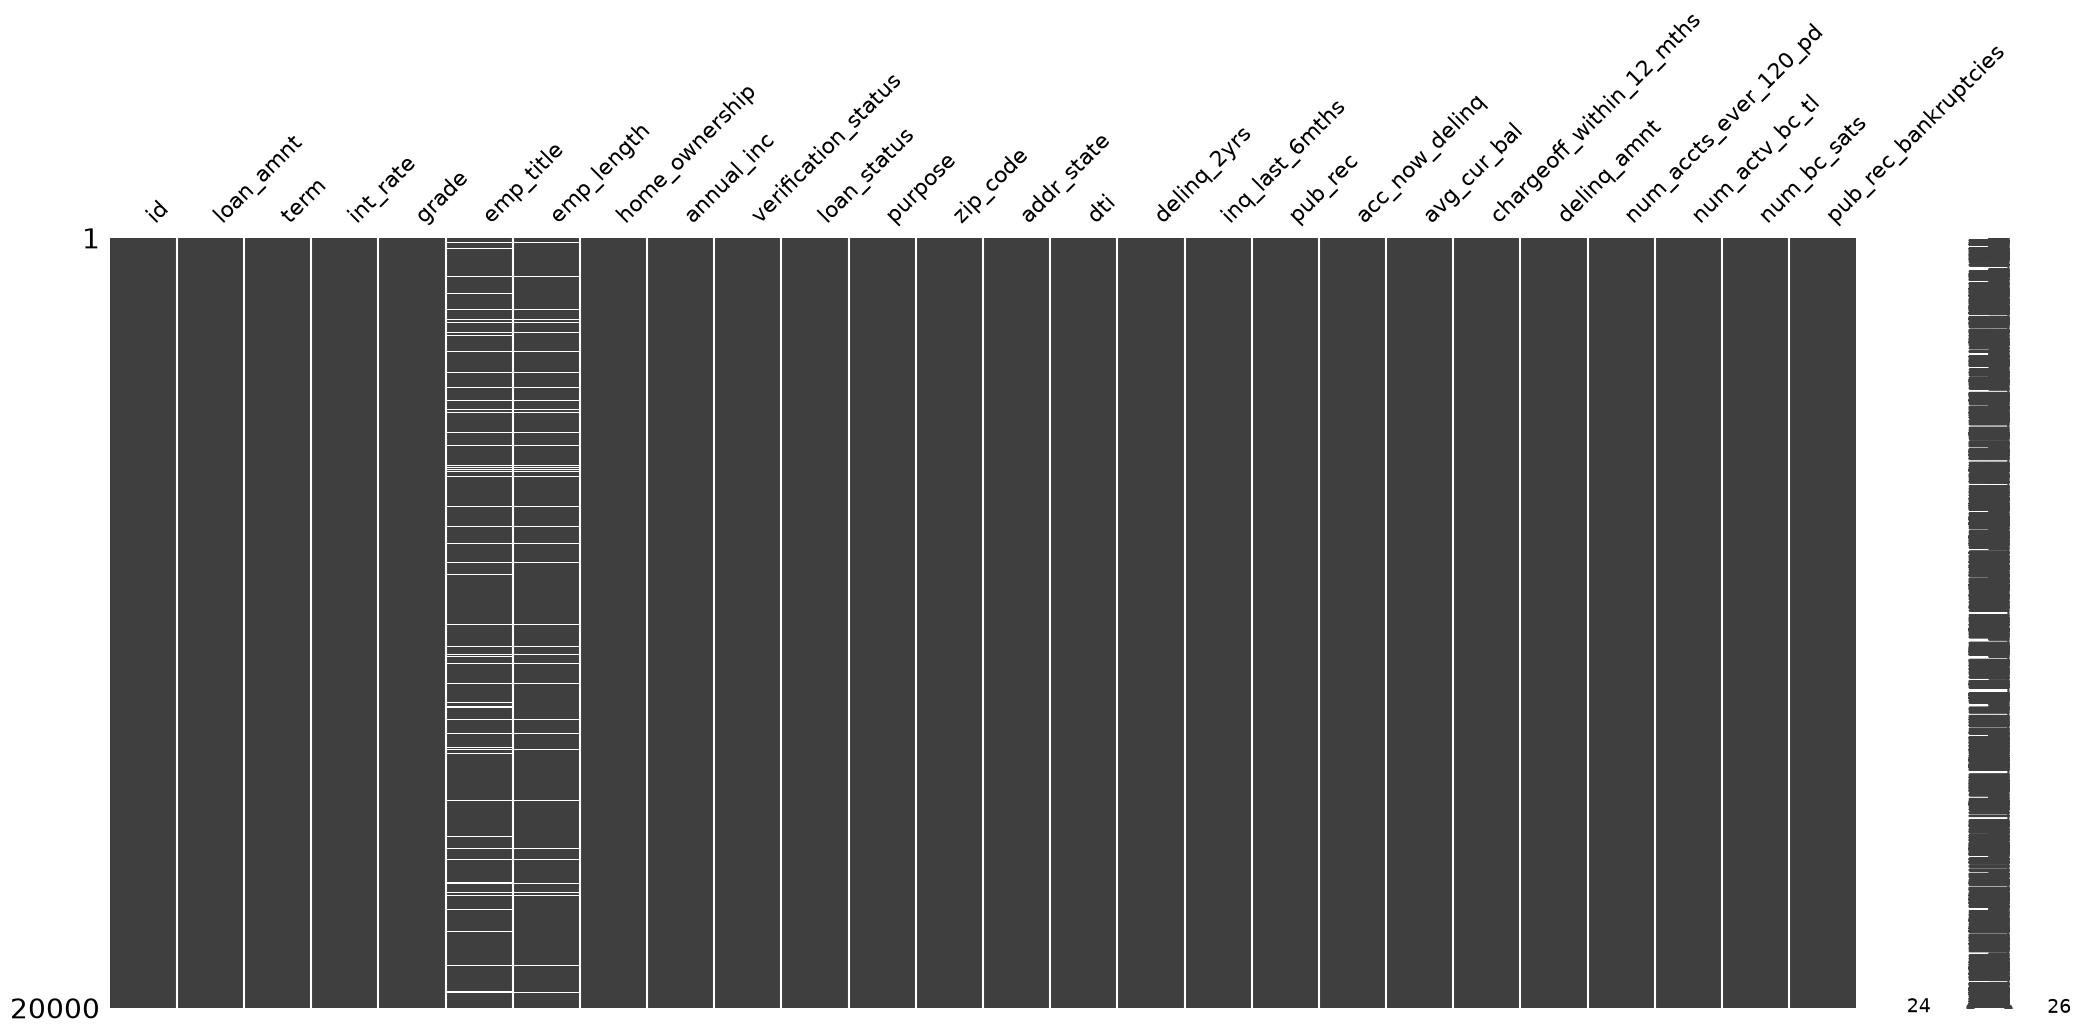

In [55]:
# Visualiser les valeurs manquantes avec missingno

msno.matrix(df)
plt.show()

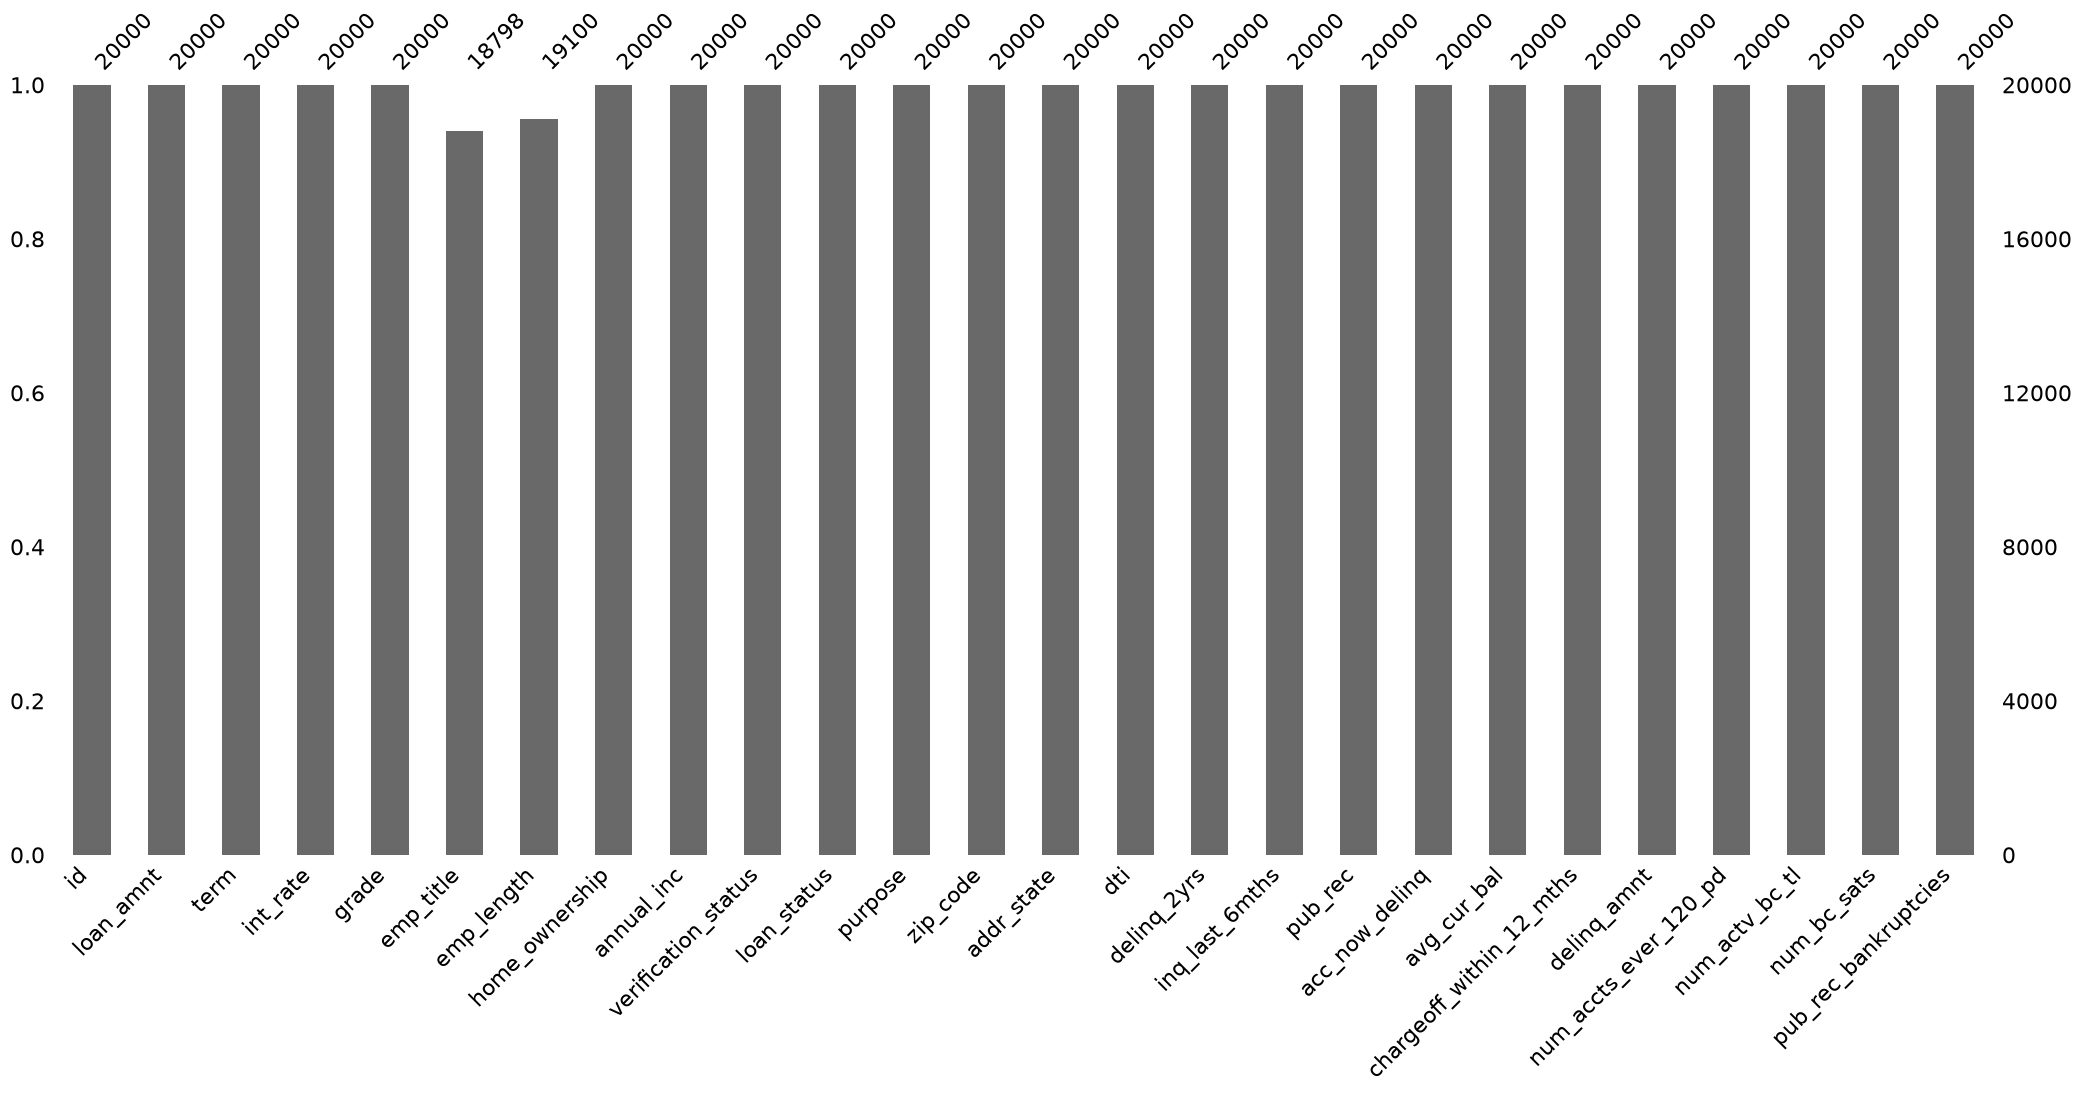

In [64]:
# Identification des valeurs manquantes avec un histogramme
msno.bar(df)
plt.show()

In [74]:
## Tableau des valeurs manquantes par colonnes. Cela permet de déterminer le pourcentage sur lequel nous pouvons supprimer les colonnesmissing_values = df.isnull().sum()

missing_values = df.isnull().sum()
missing_percent = (missing_values /len(df))*100
missing_table = pd.DataFrame({"Missing Values" : missing_values, "Percentage": missing_percent})
print(missing_table)

                          Missing Values  Percentage
id                                     0        0.00
loan_amnt                              0        0.00
term                                   0        0.00
int_rate                               0        0.00
grade                                  0        0.00
emp_title                           1202        6.01
emp_length                           900        4.50
home_ownership                         0        0.00
annual_inc                             0        0.00
verification_status                    0        0.00
loan_status                            0        0.00
purpose                                0        0.00
zip_code                               0        0.00
addr_state                             0        0.00
dti                                    0        0.00
delinq_2yrs                            0        0.00
inq_last_6mths                         0        0.00
pub_rec                                0      

In [92]:
## Vérification des doublons

df.duplicated().sum()
df["id"].duplicated().sum()

np.int64(0)

#### La vérification nous montre qu'il n'ya aucune ligne en double  dans la base

In [ ]:
### véification de certians incohérence séventuelles dans les données

print("Montants de prêt <= 0 :", (df["loan_amnt"] <= 0).sum())
print("Revenus <= 0 :", (df["annual_inc"] <= 0).sum())
print("DTI négatif :", (df["dti"] < 0).sum())

Montants de prêt <= 0 : 0
Revenus <= 0 : 0
DTI négatif : 0


In [110]:
for col in ["grade", "home_ownership", "loan_status", "purpose", "term"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


grade
grade
B    6452
C    5853
D    3061
A    2166
E    1469
F     821
G     178
Name: count, dtype: int64

home_ownership
home_ownership
MORTGAGE    10669
RENT         7488
OWN          1843
Name: count, dtype: int64

loan_status
loan_status
Fully Paid     16911
Charged Off     3089
Name: count, dtype: int64

purpose
purpose
debt_consolidation    12045
credit_card            4577
home_improvement       1097
other                  1044
major_purchase          321
small_business          212
car                     166
medical                 136
moving                  112
wedding                  99
house                    94
vacation                 92
renewable_energy          5
Name: count, dtype: int64

term
term
36 months    14122
60 months     5878
Name: count, dtype: int64


##### Il nya pas d'incohérence dans la base. Le contrôle de qualité des données montre que la base est globalement bien renseignée. La majorité des variables ne présente aucune valeur manquante. Seules les variables emp_title et emp_length comportent respectivement 6,01 % et 4,50 % de valeurs manquantes. Aucun doublon exact n’a été détecté et aucune incohérence évidente n’a été observée sur les principales variables numériques examinées. La base peut donc être utilisée pour poursuivre l’analyse exploratoire, tout en prévoyant un traitement spécifique des valeurs manquantes avant la modélisation.

## Statistique Univariée des variables: Analyse statistique et graphique des variables

## Statistique descriptive de la variable "loan_amnt"

In [102]:
df["loan_amnt"].describe()

count    20000.00000
mean     14411.72500
std       7994.63884
min       1000.00000
25%       8325.00000
50%      12375.00000
75%      20000.00000
max      35000.00000
Name: loan_amnt, dtype: float64

In [103]:
df["loan_amnt"].median()

np.float64(12375.0)

In [104]:
df["loan_amnt"].skew()

np.float64(0.6871254049453942)

##### Analyse graphique de la variable "loan_amnt"

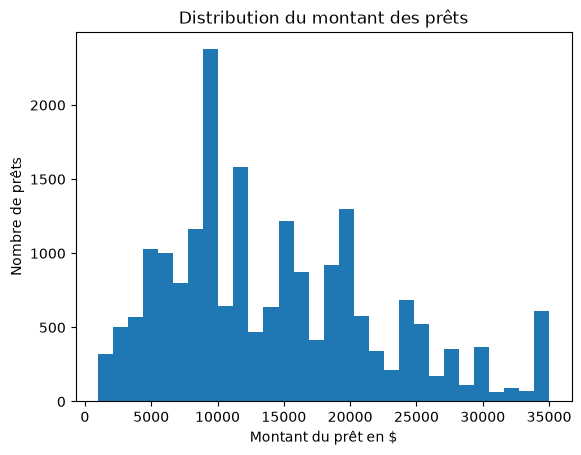

In [105]:
plt.hist(df["loan_amnt"], bins =30)
plt.xlabel("Montant du prêt en $")
plt.ylabel("Nombre de prêts")
plt.title("Distribution du montant des prêts")
plt.savefig("../reports/figures/distribution_loan_amount.pdf", bbox_inches="tight")
plt.show()

# Interprétation 

### La statisqtique descriptive montre que 20000 prêts ont été accordés. le montant moyen accordé est de 14411$. 50 % des prêts accordés sont supérieure ou égale à 12375$ et 50% sont inférieure ou égale à ce montant. le plus petit prêt accordé est de 1000$, le plus gros prët est de 35000$. Parailleurs 25% des prêts sont inférieures à 8325$ et 75% des prêts sont inférieures à 20000$. Le graphique montre une distribution asymétrique à droite. 

C:\Users\komla\AppData\Local\Temp\ipykernel_26052\2472801552.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["loan_amnt"], vert=False)


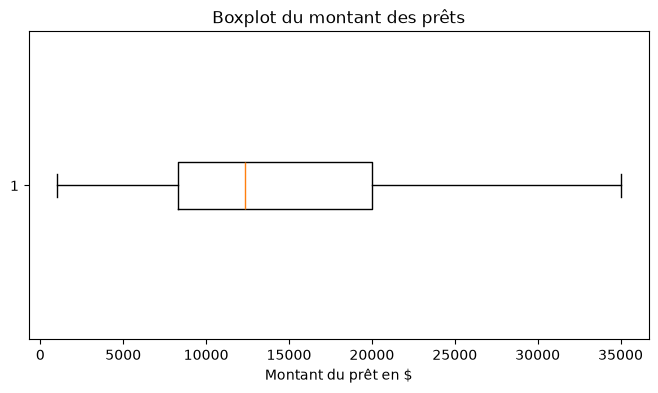

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["loan_amnt"], vert=False)
plt.xlabel("Montant du prêt en $")
plt.title("Boxplot du montant des prêts")
plt.savefig("../reports/figures/boxplot_loan_amount.pdf", bbox_inches="tight")
plt.show()

C:\Users\komla\AppData\Local\Temp\ipykernel_26052\1839973875.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["loan_amnt"], vert=False)


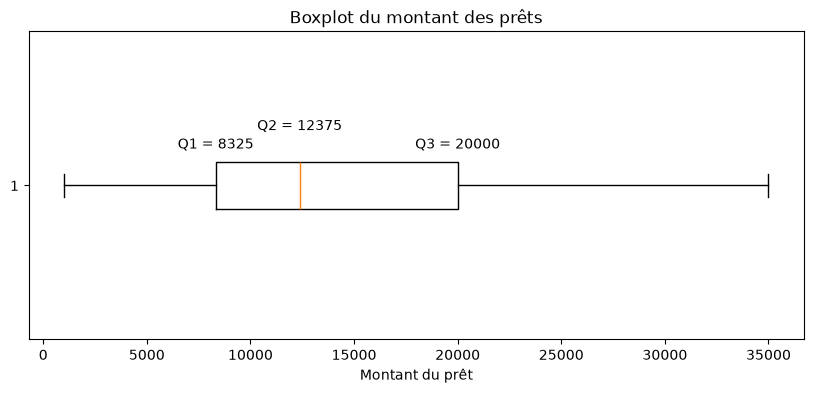

In [107]:
import matplotlib.pyplot as plt

q1 = df["loan_amnt"].quantile(0.25)
q2 = df["loan_amnt"].quantile(0.50)
q3 = df["loan_amnt"].quantile(0.75)

plt.figure(figsize=(10, 4))

plt.boxplot(df["loan_amnt"], vert=False)

plt.text(q1, 1.12, f"Q1 = {q1:.0f}", ha="center")
plt.text(q2, 1.18, f"Q2 = {q2:.0f}", ha="center")
plt.text(q3, 1.12, f"Q3 = {q3:.0f}", ha="center")

plt.xlabel("Montant du prêt")
plt.title("Boxplot du montant des prêts")
plt.savefig("../reports/figures/boxplot.pdf", bbox_inches="tight")
plt.show()

### statistique  descriptive  de la variable dti: Ratio dette / revenue

In [108]:
df["dti"]

0        12.71
1        21.07
2        12.12
3        19.16
4        15.71
         ...  
19995    18.66
19996     8.49
19997    15.60
19998    22.03
19999    12.07
Name: dti, Length: 20000, dtype: float64

In [109]:
df["dti"].describe()

count    20000.000000
mean        17.031119
std          7.561756
min          0.000000
25%         11.330000
50%         16.690000
75%         22.510000
max         34.990000
Name: dti, dtype: float64